# Project 2 — Univariate Real Series Forecasting (RNN vs LSTM vs GRU)

**Goal:** one-step-ahead forecasting on a *real* dataset with trend + seasonality — the classic **monthly airline passengers** series (1949–1960).

### What's new compared to Project 1
1. **Real data** → it has a rising trend *and* yearly seasonality. A noisy sine was stationary; this is not.
2. **Normalization** → RNNs train badly on values in the hundreds. You'll scale to ~[0,1] — and you'll fit the scaler on **train only** (the data-leakage lesson).
3. **The main event:** a head-to-head of `nn.RNN` vs `nn.LSTM` vs `nn.GRU` on the *same* data. You'll finally *measure* the long-dependency advantage you reasoned about in Project 1.

### How to use this notebook
Cells marked **`# 🛠️ TODO`** are yours. There are only three of them, all about the recurrent parts:
- fit the scaler on **train only**,
- make one model class work for **all three** cell types (the LSTM tuple-state gotcha),
- read the comparison and explain *why*.

---

## Step 0 — Imports & device
*(provided)*

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 1 — The data (monthly airline passengers)
*(provided)*

144 monthly totals (in thousands). Notice the **upward trend** and the **repeating yearly bumps** — this is what makes it harder (and more interesting) than a sine wave.

series length: 144


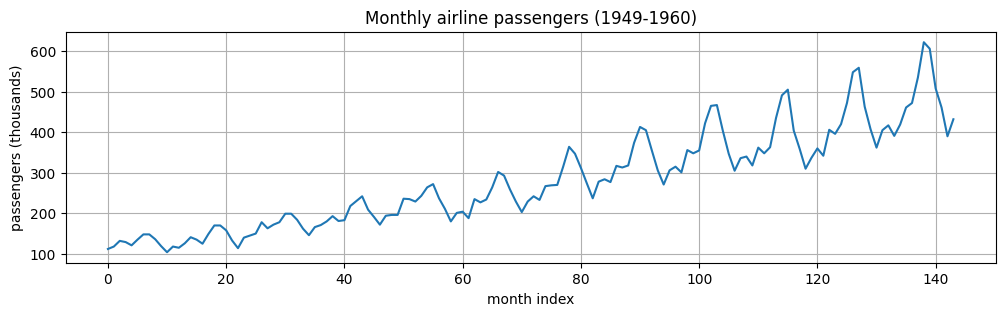

In [2]:
passengers = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432,
], dtype=np.float32)

x_0 = passengers[0]
passengers_diff = np.diff(passengers) # shape (143,0) one less than passengers

print("series length:", len(passengers))

plt.figure(figsize=(12, 3))
plt.plot(passengers)
plt.title("Monthly airline passengers (1949-1960)")
plt.xlabel("month index"); plt.ylabel("passengers (thousands)"); plt.grid(True)
plt.show()

In [3]:
x_0

np.float32(112.0)

In [4]:
passengers.shape

(144,)

## Step 2 — Time-based split (raw series first)
*(provided)*

We split **before** scaling so the scaler never sees the future. `train_raw` is the past; the last 20% is the future test region.

In [6]:
split_raw = int(0.8 * len(passengers))
train_raw = passengers[:split_raw]
print("train points:", len(train_raw), " | test points:", len(passengers) - split_raw)

# split_raw = int(0.8 * len(passengers))
# train_raw = passengers[:split_raw]
# print("train points:", len(train_raw), " | test points:", len(passengers) - split_raw)

train points: 115  | test points: 29


## Step 3 — 🛠️ Normalize (fit on TRAIN ONLY!)

RNNs struggle with raw values in the hundreds. We map everything to roughly [0, 1] with a `MinMaxScaler`.

### The leakage rule
You must **`.fit()` the scaler on `train_raw` only**, then **`.transform()`** the *whole* series with those train-derived min/max. If you fit on the full series, the min/max would leak information about the future into training — a subtle but real mistake that inflates your scores dishonestly.

`MinMaxScaler` expects a 2D array of shape `(n, 1)`, so we reshape.

In [7]:
train_raw_reshaped = train_raw.reshape(-1,1)
print(train_raw.shape, train_raw_reshaped.shape)

(115,) (115, 1)


In [9]:
scaler = MinMaxScaler()
scaler.fit(train_raw.reshape(-1,1))
# 🛠️ TODO: fit the scaler on the TRAIN portion only
#          hint: scaler.fit(train_raw.reshape(-1, 1))

# then transform the WHOLE series using the train-fitted scaler (provided)
series_scaled = scaler.transform(passengers.reshape(-1, 1)).astype(np.float32).ravel()

print("scaled range:", series_scaled.min(), "->", series_scaled.max())
# Note: test values can go slightly above 1.0 — that's expected, the trend rises beyond the train max.

scaled range: 0.0 -> 1.3385013


## Step 4 — Windowing + tensors
*(provided — same sliding-window trick as Project 1)*

In [ ]:
def make_windows(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i : i + seq_len])
        y.append(series[i + seq_len])
    X = np.array(X)[..., np.newaxis].astype(np.float32)   # (n, seq_len, 1)
    y = np.array(y)[..., np.newaxis].astype(np.float32)   # (n, 1)
    return X, y

SEQ_LEN = 12   # one year of context — a natural choice given yearly seasonality
X, y = make_windows(series_scaled, SEQ_LEN)

# split the windows at the same time boundary (targets before/after split_raw)
split = split_raw - SEQ_LEN
X_train = torch.from_numpy(X[:split]).to(device)
y_train = torch.from_numpy(y[:split]).to(device)
X_test  = torch.from_numpy(X[split:]).to(device)
y_test  = torch.from_numpy(y[split:]).to(device)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: torch.Size([103, 12, 1]) torch.Size([103, 1])
Test : torch.Size([29, 12, 1]) torch.Size([29, 1])


## Step 5 — 🛠️ One model class for RNN / LSTM / GRU

This is the heart of the project. We want a single class where you pass `cell="RNN"`, `"LSTM"`, or `"GRU"`.

### The one gotcha you must handle
The three layers return the final state **differently**:

```python
out, h_n          = self.rnn(x)   # nn.RNN  -> h_n is a tensor
out, h_n          = self.rnn(x)   # nn.GRU  -> h_n is a tensor
out, (h_n, c_n)   = self.rnn(x)   # nn.LSTM -> the state is a TUPLE (hidden, cell)
```

So if you write `out, h = self.rnn(x)`, then for an LSTM `h` will be the tuple `(h_n, c_n)`, not a tensor. Your job in `forward` is to make `last` be the **final hidden state** `(batch, hidden_size)` regardless of cell type.

`c_n` is cell memory, The output `h_t = o_t \circ tanh(c_t)` is some transformation of `c_t`, hence has same shape.

**Hint:** grab `h`, and if it's a tuple take its first element (`h[0]`), then index `[-1]` for the last layer.

In [11]:
class Forecaster(nn.Module):
    def __init__(self, cell="RNN", input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell]
        self.rnn = rnn_cls(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h = self.rnn(x)
        # 🛠️ TODO: make `last` = the final hidden state, shape (batch, hidden_size)
        #          - for LSTM, h is a tuple (h_n, c_n); for RNN/GRU, h is just h_n
        #          - take h[0] if it's a tuple, then [-1] for the last layer
        if isinstance(h, tuple):
            last = h[0][-1]
        else:
            last = h[-1]
        lin_out = self.fc(last)
        # last = h[0][-1] if isinstance(h, tuple) else h[-1]
        # raise NotImplementedError("Finish forward(): compute `last`, then return self.fc(last)")
        return lin_out

### Quick shape check (run after building the model)
*(provided)*

In [12]:
for cell in ["RNN", "LSTM", "GRU"]:
    m = Forecaster(cell=cell).to(device)
    with torch.no_grad():
        out = m(X_train[:5])
    assert out.shape == (5, 1), f"{cell}: wrong output shape {out.shape}"
    print(f"{cell:5s} OK -> {tuple(out.shape)}")
print("✅ all three cell types produce (batch, 1)")

RNN   OK -> (5, 1)
LSTM  OK -> (5, 1)
GRU   OK -> (5, 1)
✅ all three cell types produce (batch, 1)


## Step 6 — Train helper
*(provided — same 5 steps you already know, wrapped in a function)*

In [14]:
def train_model(cell, epochs=1500, lr=1e-2, hidden_size=32):
    torch.manual_seed(0)  # same init for a fair comparison
    model = Forecaster(cell=cell, hidden_size=hidden_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    # test MSE in the ORIGINAL (unscaled) units for interpretability
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test).cpu().numpy()
    pred = scaler.inverse_transform(pred_scaled).ravel()
    true = scaler.inverse_transform(y_test.cpu().numpy()).ravel()
    test_mse = np.mean((pred - true) ** 2)
    return model, losses, pred, true, test_mse

## Step 7 — The head-to-head
*(provided — but the numbers are yours to interpret)*

## Step 9 — Validation done right: forward-chaining cross-validation

A single train/test split on ~29 test points can't tell us which cell is really best. Averaging over folds gives a far more trustworthy estimate — **but for time series the folds must respect time** (training always in the past, testing always in the future). We use `TimeSeriesSplit`.

Key rule: **re-fit the scaler on each fold's training portion only** (no cross-fold leakage).

The helper `evaluate_cv` below does the per-fold machinery. Your **🛠️ TODO** is the part you asked about: loop over the three cells, and report **mean ± std** of the fold MSEs — then decide whether the RNN really wins once we account for split variance.

In [15]:
from sklearn.model_selection import TimeSeriesSplit

def evaluate_cv(cell, raw_series, seq_len=12, n_splits=5, epochs=800, lr=1e-2, hidden_size=32):
    """Forward-chaining CV. Returns an array of per-fold test MSEs (original units)."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_mses = []
    for train_idx, test_idx in tscv.split(raw_series):
        # --- per-fold scaling: fit on THIS fold's train only (no leakage) ---
        sc = MinMaxScaler().fit(raw_series[train_idx].reshape(-1, 1))
        span = raw_series[: test_idx[-1] + 1]                       # train + this fold's test
        span_scaled = sc.transform(span.reshape(-1, 1)).astype(np.float32).ravel()

        # --- window, then split windows at the train/test time boundary ---
        Xf, yf = make_windows(span_scaled, seq_len)
        b = len(train_idx) - seq_len                                # windows before this are train
        Xtr, ytr = torch.from_numpy(Xf[:b]).to(device), torch.from_numpy(yf[:b]).to(device)
        Xte, yte = torch.from_numpy(Xf[b:]).to(device), torch.from_numpy(yf[b:]).to(device)
        if len(Xtr) == 0 or len(Xte) == 0:
            continue                                                # early folds can be too short

        # --- train ---
        torch.manual_seed(0)
        model = Forecaster(cell=cell, hidden_size=hidden_size).to(device)
        opt, crit = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
        for _ in range(epochs):
            model.train(); opt.zero_grad()
            loss = crit(model(Xtr), ytr); loss.backward(); opt.step()

        # --- test MSE in original units ---
        model.eval()
        with torch.no_grad():
            p = sc.inverse_transform(model(Xte).cpu().numpy()).ravel()
            t = sc.inverse_transform(yte.cpu().numpy()).ravel()
        fold_mses.append(float(np.mean((p - t) ** 2)))
    return np.array(fold_mses)

for cell in ["RNN", "LSTM", "GRU"]:
    mses = evaluate_cv(cell, passengers)
    print(cell, mses.mean(), mses.std(), mses)
# 🛠️ TODO: loop over ["RNN", "LSTM", "GRU"], call evaluate_cv on the RAW `passengers`,
#          and print mean ± std of the fold MSEs. Then answer: does any cell win
#          once the std bars overlap?
# Example of one call:
#   mses = evaluate_cv("RNN", passengers)
#   print("RNN", mses.mean(), mses.std(), mses)

RNN 1646.7816284179687 1308.8391143192457 [ 858.58081055  429.2487793  4003.36523438  820.73455811 2121.97875977]
LSTM 2561.3703491210936 1606.9749657130628 [2151.00878906  695.96563721 3285.09960938 1396.31726074 5278.46044922]
GRU 1756.6546752929687 2110.600691009159 [ 285.20291138  420.84115601 1687.07580566  532.3102417  5857.84326172]


In [16]:
results = {}
for cell in ["RNN", "LSTM", "GRU"]:
    model, losses, pred, true, test_mse = train_model(cell)
    results[cell] = dict(losses=losses, pred=pred, true=true, mse=test_mse)
    print(f"{cell:5s} | test MSE (original units): {test_mse:9.2f}")

RNN   | test MSE (original units):   1869.68
LSTM  | test MSE (original units):   2827.01
GRU   | test MSE (original units):   1218.47


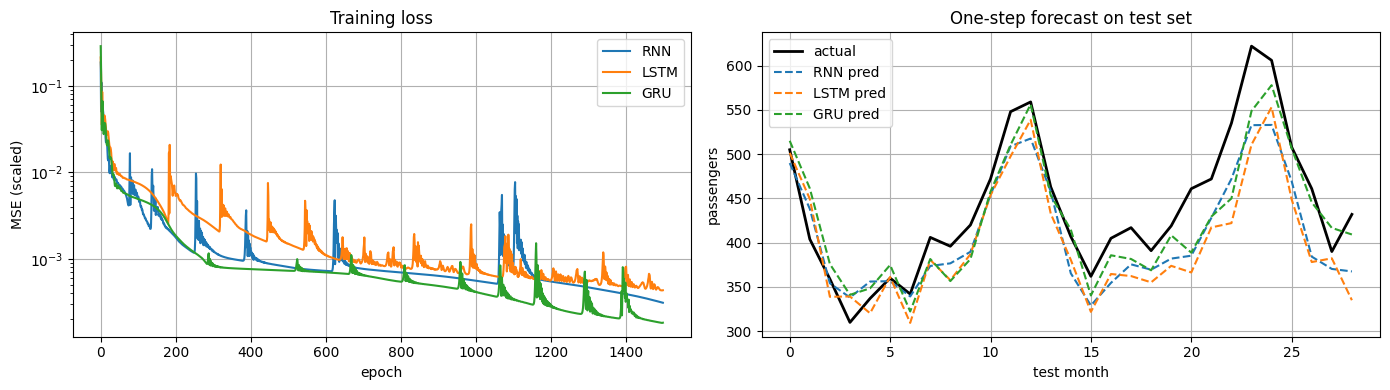

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for cell in ["RNN", "LSTM", "GRU"]:
    ax1.plot(results[cell]["losses"], label=cell)
ax1.set_title("Training loss"); ax1.set_xlabel("epoch"); ax1.set_ylabel("MSE (scaled)")
ax1.set_yscale("log"); ax1.legend(); ax1.grid(True)

ax2.plot(results["RNN"]["true"], "k", linewidth=2, label="actual")
for cell in ["RNN", "LSTM", "GRU"]:
    ax2.plot(results[cell]["pred"] , "--", label=f"{cell} pred")
ax2.set_title("One-step forecast on test set"); ax2.set_xlabel("test month"); ax2.set_ylabel("passengers")
ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Step 8 — 🛠️ Reflect

1. **Leakage:** What exactly would go wrong if you fit the `MinMaxScaler` on the *full* series instead of train only? Why is it dishonest even though the code runs fine?
> Then we would be using even on future data!! And future data practically is not available 
2. **The tuple gotcha:** In one sentence, why does `nn.LSTM` return `(h_n, c_n)` while `nn.RNN`/`nn.GRU` return only `h_n`? What is `c_n`? -> `c_n` is memory cell.
3. **The comparison:** Which cell won? Look at both the *loss curves* and the *test MSE*. Does LSTM/GRU beat vanilla RNN here — and if the gap is small, why might that be (hint: `SEQ_LEN=12` is short)? -> Actually `RNN` performed better than LSTM, but worse than GRU.
4. **Experiments to try:**
   - Increase `SEQ_LEN` to 24 or 36. Does the RNN degrade faster than LSTM/GRU? (This is where the gap should widen.)
   > With `SEQ_LEN` = 24, performance for the models improved. However, RNN now does the best.
   > With `SEQ_LEN` = 36, the performance of basic RNN further improved but for GRU/LSTM it degraded. `Surprising?`
   - Try `hidden_size=16` vs `64`. -> hidden size change has not drastic effect and it makes sense as it is width of network.
   - The data has a clear trend — try predicting the **difference** `series[t] - series[t-1]` instead of the raw level. Does it help? 
   > LSTM started performing way better than RNN and GRU when I did perform prediction on the difference. And Honestly I have no answer why?

---
Fill in the 🛠️ TODOs, run it, and send me your comparison numbers + your read on *why*. Then we move to **Project 3** (multivariate).

### Summary
1. Model capacity must match data size \rightarrow Fancier model + tiny data = worse generalization.  
> Number of parameters for $RNN \approx 1x, GRU \approx 3x, LSTM \approx 4x$. 

2. LSTM/GRU are not "better networks." They are better when *the problem needs long memory and you have enough data to train them.*

3. Predicting a bounded, stationary quantity is simply easier.

4. A single run cannot tell you which architecture is "better" on data. A change of the seed and the ranking can flip. `Proper Validation!`
5. The gold standard validation: **2D design: folder x seeds**:
   1. Average over **seeds** removes init noise - keep split fixed
   2. Average over **folds** removes split noise - keep seed fixed
   3. **Paired** fold by fold comparison
